In [1]:
import xarray as xr
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [14]:
ds = xr.open_dataset("/home/has/data/sources/icon/ICON312_v1.0.0.zarr")
data = ds['tqc_dia'].isel(time=400)

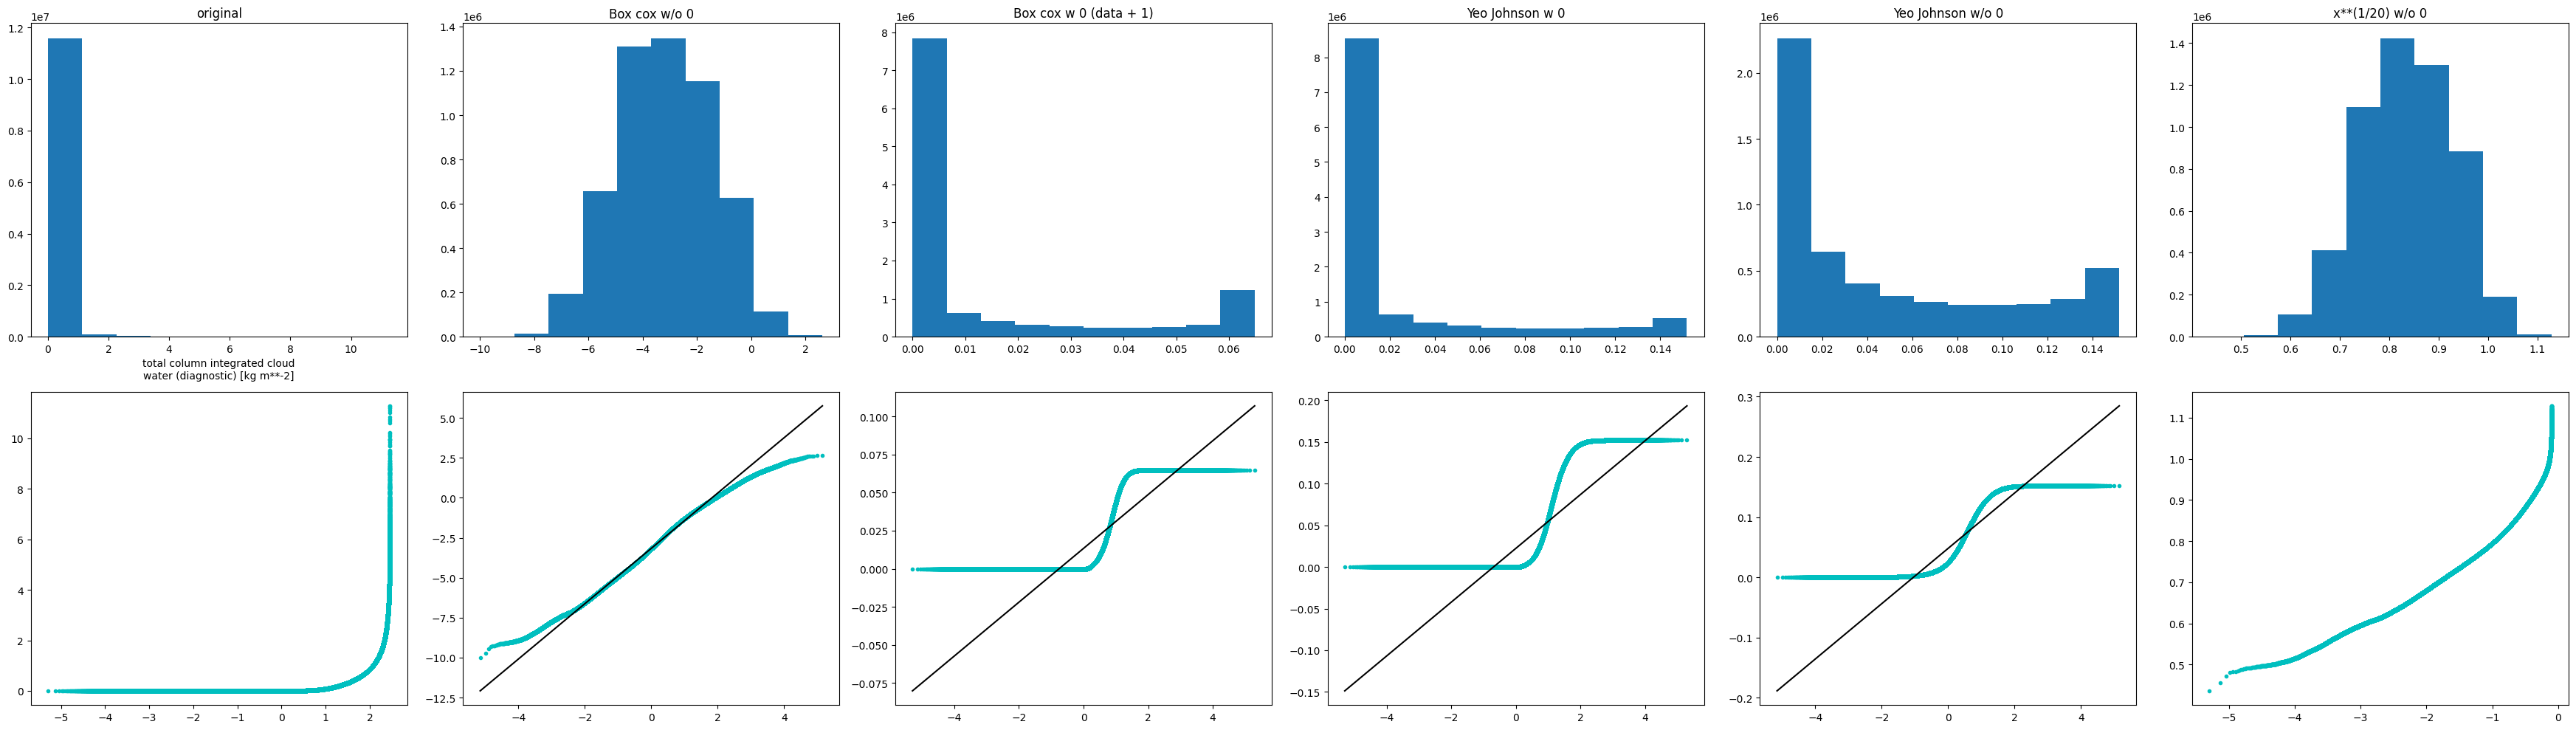

In [15]:
fig = plt.figure(figsize=(35,10))
axes = fig.subplots(2,6);
fax = axes.flatten()
#Original data
data.plot.hist(ax=fax[0]);
fax[0].set_title('original')
(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data)
fax[6].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#Boxcox
fax[1].set_title('Box cox w/o 0')
data_transformed = scipy.stats.boxcox(data.where(data>0).dropna('cell'));
fax[1].hist(data_transformed[0]);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed[0])
fax[7].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#Boxcox
fax[2].set_title('Box cox w 0 (data + 1)')
data_transformed = scipy.stats.boxcox((data+1).dropna('cell'));
fax[2].hist(data_transformed[0]);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed[0])
fax[8].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#YeoJohnson (incl. zeros)
fax[3].set_title('Yeo Johnson w 0')
data_transformed = scipy.stats.yeojohnson(data.dropna('cell'));
fax[3].hist(data_transformed[0]);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed[0])
fax[9].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#YeoJohnson (excl. zeros)
fax[4].set_title('Yeo Johnson w/o 0')
data_transformed = scipy.stats.yeojohnson(data.where(data>0).dropna('cell'));
fax[4].hist(data_transformed[0]);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed[0])
fax[10].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#Root
fax[5].set_title('x**(1/20) w/o 0')
data_transformed = data.where(data>0)**(1/20)
fax[5].hist(data_transformed);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed)
fax[11].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

plt.tight_layout()


-9.996642


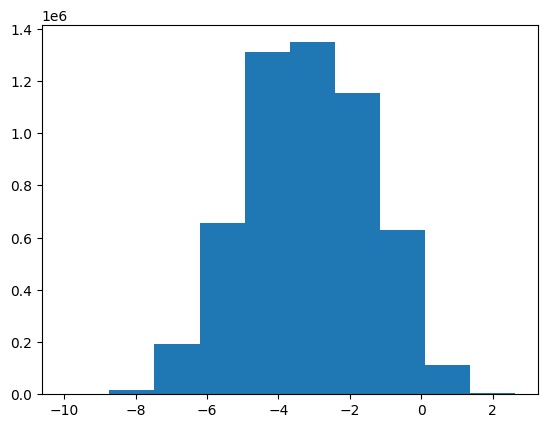

In [16]:
data_transformed = scipy.stats.boxcox(data.where(data>0).dropna('cell'));
plt.hist(data_transformed[0]);
print(np.min(data_transformed[0]))

In [17]:
data_transformed[1]

0.06734592092482214

In [22]:
lmbda = 0.6
y = data_transformed[0]
x = (lmbda*y + 1)**1/lmbda

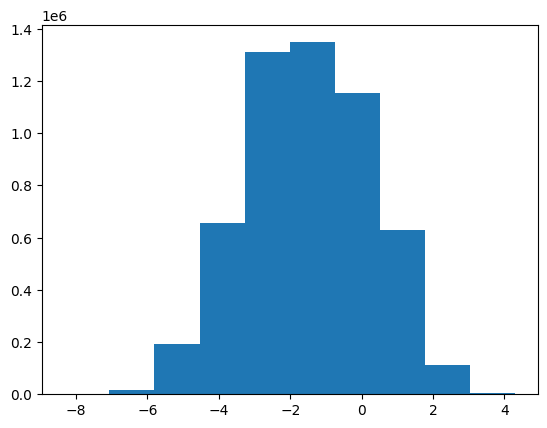

In [23]:
plt.hist(x);

(array([5.20446e+05, 1.51252e+05, 6.46080e+04, 2.58570e+04, 8.96000e+03,
        2.77500e+03, 7.26000e+02, 1.69000e+02, 3.10000e+01, 1.60000e+01]),
 array([3.14001575e-10, 4.80045080e-01, 9.60090160e-01, 1.44013524e+00,
        1.92018032e+00, 2.40022540e+00, 2.88027048e+00, 3.36031556e+00,
        3.84036064e+00, 4.32040596e+00, 4.80045080e+00]),
 <BarContainer object of 10 artists>)

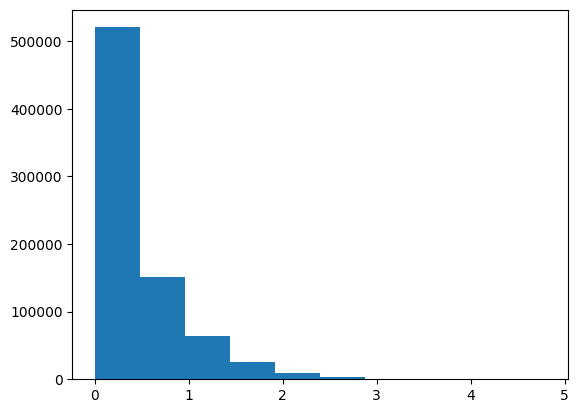

In [9]:
plt.hist(scipy.special.inv_boxcox(y, 0.6))

## Implementation test

In [10]:
import xarray as xr

In [11]:
ds_boundary = xr.open_zarr("../data/experiment/data/datastore.boundary.domain03.zarr")
ds_interior = xr.open_zarr("../data/experiment/data/datastore.interior.domain03.zarr")

In [12]:
ds_forcing = ds_boundary.sel(forcing_feature=["tqc_dia"])
ds_forcing

<xarray.Dataset> Size: 4GB
Dimensions:                         (forcing_feature: 1, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2, static_feature: 1)
Coordinates: (12/14)
  * forcing_feature                 (forcing_feature) <U15 60B 'tqc_dia'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
  * static_feature                  (static_feature) <U3 12B 'lsm'
    ...                              ...
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_long_name        (static_feature) <U1 4B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_source_dataset   (static_feature) <U15 60B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_units            (static_feature) <U1 4B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 4GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    splits                          (split_name, split_part) <U16 384B dask.array<chunksize=(3, 2), meta=np.ndarray>
    static                          (static_feature, grid_index) float64 798kB dask.array<chunksize=(1, 99797), meta=np.ndarray>
    static__train__mean             (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static__train__std              (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

In [13]:
ds_forcing.forcing

<xarray.DataArray 'forcing' (forcing_feature: 1, time: 5543, grid_index: 99797)> Size: 4GB
dask.array<getitem, shape=(1, 5543, 99797), dtype=float64, chunksize=(1, 1, 99797), chunktype=numpy.ndarray>
Coordinates:
  * forcing_feature                 (forcing_feature) <U15 60B 'tqc_dia'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
    clat                            (grid_index) float64 798kB dask.array<chunksize=(99797,), meta=np.ndarray>
    clon                            (grid_index) float64 798kB dask.array<chunksize=(99797,), meta=np.ndarray>
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    CDI_grid_type:                unstructured
    long_name:                    zonal wind in 10m
    number_of_grid_in_reference:  1
    param:                        2.2.0
    standard_name:                u_10m
    units:                        m s-1
    variables_mapping_dim:        forcing_feature

In [24]:
# data_positive = ds_forcing.forcing.where(ds_forcing.forcing>0).dropna('grid_index')
# data_transformed = scipy.special.boxcox(data_positive, 0.6)
data_transformed_w_zeros = xr.where(ds_forcing.forcing > 0, scipy.special.boxcox(ds_forcing.forcing, 0.6), -12)
ds_forcing["forcing"] = data_transformed_w_zeros

In [25]:
import yaml
config = yaml.safe_load(ds_forcing.attrs['creation_config'])

In [26]:
config['output']['splitting']['splits']['train']

{'compute-statistics': {'dims': ['grid_index', 'time'],
  'ops': ['mean', 'std', 'diff_mean', 'diff_std']},
 'end': '2020-01-31T10:00',
 'start': '2020-01-11T23:00'}

In [27]:
ds_split = ds_forcing.sel(
    {"time": slice(config['output']['splitting']['splits']['train']['start'], config['output']['splitting']['splits']['train']['end'])}
)


ds_forcing['forcing__train__diff_mean'] = ds_split.forcing.diff(dim='train').mean(dim=['time','grid_index'])
ds_forcing['forcing__train__diff_std'] = ds_split.forcing.diff(dim='train').std(dim=['time','grid_index'])
ds_forcing['forcing__train__mean'] = ds_split.forcing.mean(dim=['time','grid_index'])
ds_forcing['forcing__train__std'] = ds_split.forcing.std(dim=['time','grid_index'])

In [28]:
ds_forcing

<xarray.Dataset> Size: 4GB
Dimensions:                         (forcing_feature: 1, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2, static_feature: 1)
Coordinates: (12/14)
  * forcing_feature                 (forcing_feature) <U15 60B 'tqc_dia'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
  * static_feature                  (static_feature) <U3 12B 'lsm'
    ...                              ...
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_long_name        (static_feature) <U1 4B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_source_dataset   (static_feature) <U15 60B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_units            (static_feature) <U1 4B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 4GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    splits                          (split_name, split_part) <U16 384B dask.array<chunksize=(3, 2), meta=np.ndarray>
    static                          (static_feature, grid_index) float64 798kB dask.array<chunksize=(1, 99797), meta=np.ndarray>
    static__train__mean             (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static__train__std              (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

In [29]:
ds_forcing_out = ds_forcing.drop_vars(['clon','clat','static_feature_long_name','static_feature_source_dataset','static_feature_units','static','splits','static__train__mean','static__train__std'])

In [30]:
ds_forcing_out

<xarray.Dataset> Size: 4GB
Dimensions:                         (forcing_feature: 1, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2, static_feature: 1)
Coordinates:
  * forcing_feature                 (forcing_feature) <U15 60B 'tqc_dia'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
  * static_feature                  (static_feature) <U3 12B 'lsm'
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 4GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

In [31]:
import zarr
import numcodecs
from numcodecs import Blosc

compressor = Blosc(cname="zstd", clevel=1, shuffle=2)

In [32]:
encoding = {}
for var in ds_forcing_out.data_vars:
    encoding[var] = {'compressor': ds_boundary[var].encoding['compressor']}

In [33]:
ds_forcing_out.to_zarr("../data/experiment/data/datastore.boundary.domain03.boxcoxtqc.zarr", mode='w', encoding=encoding)

In [34]:
ds_forcing_out

<xarray.Dataset> Size: 4GB
Dimensions:                         (forcing_feature: 1, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2, static_feature: 1)
Coordinates:
  * forcing_feature                 (forcing_feature) <U15 60B 'tqc_dia'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
  * static_feature                  (static_feature) <U3 12B 'lsm'
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 4GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

In [35]:
encoding

{'forcing': {'compressor': Blosc(cname='zstd', clevel=1, shuffle=BITSHUFFLE, blocksize=0)},
 'forcing__train__diff_mean': {'compressor': Blosc(cname='zstd', clevel=1, shuffle=BITSHUFFLE, blocksize=0)},
 'forcing__train__diff_std': {'compressor': Blosc(cname='zstd', clevel=1, shuffle=BITSHUFFLE, blocksize=0)},
 'forcing__train__mean': {'compressor': Blosc(cname='zstd', clevel=1, shuffle=BITSHUFFLE, blocksize=0)},
 'forcing__train__std': {'compressor': Blosc(cname='zstd', clevel=1, shuffle=BITSHUFFLE, blocksize=0)}}

In [36]:
ds = xr.open_zarr('reference://', storage_options={'fo': "../index.boundary.boxcoxtqc.json"})

FileNotFoundError: [Errno 2] No such file or directory: '/home/has/repos/mllam-exps-ShCu/notebooks/../index.boundary.boxcoxtqc.json'

In [56]:
ds

<xarray.Dataset> Size: 62GB
Dimensions:                         (forcing_feature: 14, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2, static_feature: 1)
Coordinates: (12/14)
  * forcing_feature                 (forcing_feature) <U15 840B 'u_10m' ... '...
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
  * static_feature                  (static_feature) <U3 12B 'lsm'
    ...                              ...
    forcing_feature_long_name       (forcing_feature) object 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) object 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) object 112B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_long_name        (static_feature) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_source_dataset   (static_feature) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_units            (static_feature) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 62GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    splits                          (split_name, split_part) object 48B dask.array<chunksize=(3, 2), meta=np.ndarray>
    static                          (static_feature, grid_index) float64 798kB dask.array<chunksize=(1, 99797), meta=np.ndarray>
    static__train__mean             (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static__train__std              (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

(array([8.6019e+04, 2.0000e+00, 2.1400e+02, 1.8640e+03, 2.0320e+03,
        2.3070e+03, 2.2020e+03, 2.1660e+03, 1.8510e+03, 1.1400e+03]),
 array([-90.        , -81.50530336, -73.01060671, -64.51591007,
        -56.02121342, -47.52651678, -39.03182013, -30.53712349,
        -22.04242684, -13.5477302 ,  -5.05303355]),
 <BarContainer object of 10 artists>)

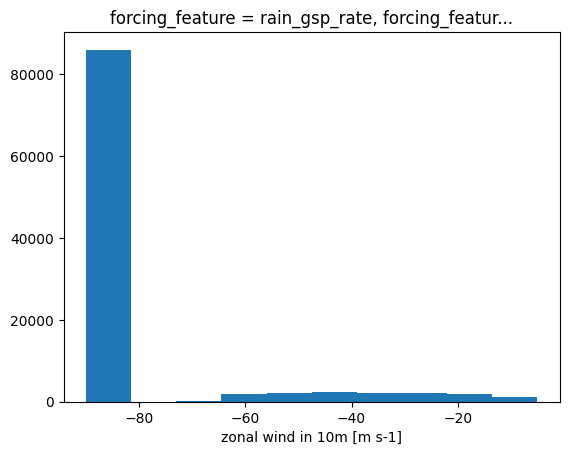

In [59]:
ds.forcing.sel(forcing_feature='rain_gsp_rate').isel(time=0).plot.hist()

In [60]:
## Interior

In [37]:
ds_interior.attrs = None

In [38]:
ds_state = ds_interior.sel(state_feature=['tqc_dia'])

In [39]:
data_transformed_w_zeros = xr.where(ds_state.state > 0, scipy.special.boxcox(ds_state.state, 0.6), -12)
ds_state["state"] = data_transformed_w_zeros

In [40]:
ds_split = ds_state.sel(
    {"time": slice(config['output']['splitting']['splits']['train']['start'], config['output']['splitting']['splits']['train']['end'])}
)


ds_state['state__train__diff_mean'] = ds_split.state.diff(dim='train').mean(dim=['time','grid_index'])
ds_state['state__train__diff_std'] = ds_split.state.diff(dim='train').std(dim=['time','grid_index'])
ds_state['state__train__mean'] = ds_split.state.mean(dim=['time','grid_index'])
ds_state['state__train__std'] = ds_split.state.std(dim=['time','grid_index'])

In [41]:
ds_state_out = ds_state.drop_vars(['forcing', 'forcing__train__diff_mean', 'forcing__train__diff_std', 'forcing__train__mean',
                    'forcing__train__std', 'splits', 'static', 'static__train__mean', 'static__train__std', 'clat', 'clon',])

In [42]:
encoding = {}
for var in ds_state_out.data_vars:
    encoding[var] = {'compressor': ds_interior[var].encoding['compressor']}

ds_state_out.to_zarr("../data/experiment/data/datastore.interior.domain03.boxcoxtqc.zarr", mode='w', encoding=encoding)